# Notebook 01 - Preparacion de datos y features

Este notebook limpia los datasets obligatorios, construye variables de ranking, forma reciente,
enfrentamientos directos y atributos agregados de jugadores. Tambien reconstruye los 12 grupos
del Mundial 2026 desde el calendario.

In [1]:
from pathlib import Path  # Permite usar rutas compatibles con Windows y Colab.
import json  # Guarda estructuras como los grupos en formato reutilizable.
import warnings  # Controla avisos menores durante la ejecucion.

import numpy as np  # Realiza calculos numericos y manejo de arreglos.
import pandas as pd  # Carga y transforma los archivos CSV.
import matplotlib.pyplot as plt  # Genera graficos de verificacion.

warnings.filterwarnings("ignore")  # Evita que avisos repetidos oculten la salida importante.
pd.set_option("display.max_columns", 120)  # Muestra suficientes columnas al inspeccionar tablas.
plt.style.use("ggplot")  # Usa un estilo grafico disponible sin dependencias extra.

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()  # Detecta raiz del proyecto.
DATA_DIR = ROOT  # Define donde estan las carpetas archive.
OUT_DATA = ROOT / "artifacts" / "data"  # Define carpeta de datos procesados.
OUT_DATA.mkdir(parents=True, exist_ok=True)  # Crea carpeta de salida si no existe.

PATH_RESULTS = DATA_DIR / "archive (4)" / "results.csv"  # Historial internacional de partidos.
PATH_RANKING_HISTORY = DATA_DIR / "archive (5)" / "fifa_ranking-2024-06-20.csv"  # Ranking FIFA historico.
PATH_RANKING_2026 = DATA_DIR / "archive (3)" / "fifa_ranking_2026-06-08.csv"  # Ranking usado para simular 2026.
PATH_PLAYERS = DATA_DIR / "archive (6)" / "players_21.csv"  # Atributos FIFA de jugadores.
PATH_SCHEDULE = DATA_DIR / "archive (3)" / "schedule_2026.csv"  # Calendario de grupos 2026.
PATH_WORLD_CUP = DATA_DIR / "archive (3)" / "world_cup.csv"  # Campeones historicos.

In [3]:
results_raw = pd.read_csv(PATH_RESULTS)  # Carga el historial de partidos.
ranking_history_raw = pd.read_csv(PATH_RANKING_HISTORY)  # Carga ranking FIFA por fecha.
ranking_2026_raw = pd.read_csv(PATH_RANKING_2026)  # Carga ranking de referencia para 2026.
players_raw = pd.read_csv(PATH_PLAYERS)  # Carga jugadores y atributos.
schedule_raw = pd.read_csv(PATH_SCHEDULE)  # Carga partidos programados de 2026.
world_cup_raw = pd.read_csv(PATH_WORLD_CUP)  # Carga campeones por edicion.

print("Partidos:", results_raw.shape)  # Muestra tamano del historial.
print("Ranking historico:", ranking_history_raw.shape)  # Muestra tamano del ranking.
print("Jugadores:", players_raw.shape)  # Muestra tamano de jugadores.
print("Calendario 2026:", schedule_raw.shape)  # Muestra partidos 2026.

Partidos: (49477, 9)
Ranking historico: (67472, 8)
Jugadores: (18944, 106)
Calendario 2026: (72, 10)


In [4]:
NAME_MAP = {  # Unifica nombres distintos entre fuentes.
    "Bosnia Herzegovina": "Bosnia-Herzegovina",  # Une jugadores con calendario.
    "Bosnia and Herzegovina": "Bosnia-Herzegovina",  # Une ranking/resultados con calendario.
    "Czech Republic": "Czechia",  # Usa nombre moderno.
    "DR Congo": "Congo DR",  # Usa forma del calendario.
    "Iran": "IR Iran",  # Usa forma FIFA.
    "Ivory Coast": "Côte d'Ivoire",  # Usa forma FIFA.
    "South Korea": "Korea Republic",  # Usa forma FIFA.
    "Turkey": "Türkiye",  # Usa forma del calendario.
    "Curacao": "Curaçao",  # Conserva forma del calendario.
    "United States of America": "United States",  # Une variantes del pais.
    "USA": "United States",  # Une abreviatura.
}  # Termina diccionario de nombres.

def clean_team(name):  # Define limpieza reusable.
    if pd.isna(name):  # Mantiene valores faltantes.
        return name  # Devuelve NaN sin modificar.
    text = str(name).strip()  # Quita espacios alrededor.
    return NAME_MAP.get(text, text)  # Aplica equivalencia si existe.

In [5]:
results = results_raw.copy()  # Crea copia del historial.
results["date"] = pd.to_datetime(results["date"], errors="coerce")  # Convierte fechas.
results["home_team"] = results["home_team"].map(clean_team)  # Normaliza equipo local.
results["away_team"] = results["away_team"].map(clean_team)  # Normaliza equipo visitante.
results = results.dropna(subset=["date", "home_score", "away_score"])  # Quita partidos sin marcador.
results["home_score"] = results["home_score"].astype(int)  # Asegura goles locales enteros.
results["away_score"] = results["away_score"].astype(int)  # Asegura goles visitantes enteros.
results = results[results["date"] >= "1993-01-01"].sort_values("date").reset_index(drop=True)  # Usa etapa con ranking FIFA.
results["match_id"] = np.arange(len(results))  # Crea identificador unico.

ranking_history = ranking_history_raw.copy()  # Copia ranking historico.
ranking_history["team"] = ranking_history["country_full"].map(clean_team)  # Normaliza pais.
ranking_history["rank_date"] = pd.to_datetime(ranking_history["rank_date"], errors="coerce")  # Convierte fecha de ranking.
ranking_history = ranking_history.rename(columns={"total_points": "ranking_points"})  # Renombra puntos.
ranking_history = ranking_history[["team", "rank_date", "rank", "ranking_points"]].dropna(subset=["rank_date"])  # Conserva columnas utiles.
ranking_history = ranking_history.sort_values(["team", "rank_date"]).drop_duplicates(["team", "rank_date"])  # Evita duplicados.

ranking_2026 = ranking_2026_raw.copy()  # Copia ranking 2026.
ranking_2026["team"] = ranking_2026["team"].map(clean_team)  # Normaliza nombres.
ranking_2026 = ranking_2026.rename(columns={"points": "ranking_points"})  # Usa mismo nombre de puntos.

In [6]:
schedule = schedule_raw.copy()  # Copia calendario.
schedule["home_team"] = schedule["home_team"].map(clean_team)  # Normaliza local.
schedule["away_team"] = schedule["away_team"].map(clean_team)  # Normaliza visitante.
schedule["order"] = np.arange(len(schedule))  # Guarda orden original.

graph = {}  # Crea grafo equipo-rival para detectar grupos.
first_seen = {}  # Guarda primera aparicion por equipo.
for row in schedule.itertuples():  # Recorre partidos de grupo.
    graph.setdefault(row.home_team, set()).add(row.away_team)  # Conecta local con visitante.
    graph.setdefault(row.away_team, set()).add(row.home_team)  # Conecta visitante con local.
    first_seen.setdefault(row.home_team, row.order)  # Registra aparicion local.
    first_seen.setdefault(row.away_team, row.order)  # Registra aparicion visitante.

groups = {}  # Guarda grupos reconstruidos.
visited = set()  # Guarda equipos ya procesados.
for seed in sorted(graph, key=lambda x: first_seen[x]):  # Recorre equipos por aparicion.
    if seed in visited:  # Evita repetir componentes.
        continue  # Salta si ya fue asignado.
    stack = [seed]  # Inicia busqueda.
    component = []  # Guarda componente del grupo.
    visited.add(seed)  # Marca semilla.
    while stack:  # Explora vecinos.
        team = stack.pop()  # Toma equipo pendiente.
        component.append(team)  # Agrega a componente.
        for opponent in graph[team]:  # Recorre rivales.
            if opponent not in visited:  # Solo toma no visitados.
                visited.add(opponent)  # Marca rival.
                stack.append(opponent)  # Programa rival.
    label = chr(ord("A") + len(groups))  # Crea etiqueta A-L.
    groups[label] = sorted(component, key=lambda x: first_seen[x])  # Ordena equipos por calendario.

(OUT_DATA / "groups_2026.json").write_text(json.dumps(groups, ensure_ascii=False, indent=2), encoding="utf-8")  # Guarda grupos.
print(groups)  # Muestra grupos reconstruidos.

{'A': ['Mexico', 'South Africa', 'Korea Republic', 'Czechia'], 'B': ['Canada', 'Bosnia-Herzegovina', 'Switzerland', 'Qatar'], 'C': ['United States', 'Paraguay', 'Türkiye', 'Australia'], 'D': ['Brazil', 'Morocco', 'Scotland', 'Haiti'], 'E': ['Germany', 'Curaçao', "Côte d'Ivoire", 'Ecuador'], 'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'], 'G': ['Belgium', 'Egypt', 'New Zealand', 'IR Iran'], 'H': ['Spain', 'Cape Verde', 'Uruguay', 'Saudi Arabia'], 'I': ['France', 'Senegal', 'Iraq', 'Norway'], 'J': ['Argentina', 'Algeria', 'Jordan', 'Austria'], 'K': ['Portugal', 'Congo DR', 'Uzbekistan', 'Colombia'], 'L': ['England', 'Croatia', 'Ghana', 'Panama']}

In [7]:
def attach_rank(df, side):  # Une ranking previo a cada partido.
    team_col = f"{side}_team"  # Define columna del equipo.
    pieces = []  # Acumula partes por seleccion.
    for team, part in df.groupby(team_col):  # Procesa cada seleccion.
        left = part[["match_id", "date"]].sort_values("date")  # Toma fechas de sus partidos.
        hist = ranking_history[ranking_history["team"] == team].sort_values("rank_date")  # Toma ranking del equipo.
        if hist.empty:  # Maneja equipos sin ranking.
            merged = left.assign(rank=np.nan, ranking_points=np.nan)  # Crea faltantes controlados.
        else:  # Si hay ranking disponible.
            merged = pd.merge_asof(left, hist, left_on="date", right_on="rank_date", direction="backward")  # Une ranking anterior.
        pieces.append(merged[["match_id", "rank", "ranking_points"]])  # Guarda columnas utiles.
    out = pd.concat(pieces, ignore_index=True)  # Une todas las selecciones.
    return out.rename(columns={"rank": f"{side}_rank", "ranking_points": f"{side}_ranking_points"})  # Prefija columnas.

matches = results.copy()  # Crea tabla modelable.
matches = matches.merge(attach_rank(matches, "home"), on="match_id", how="left")  # Une ranking local.
matches = matches.merge(attach_rank(matches, "away"), on="match_id", how="left")  # Une ranking visitante.
matches["home_rank"] = matches["home_rank"].fillna(211)  # Imputa peor ranking local.
matches["away_rank"] = matches["away_rank"].fillna(211)  # Imputa peor ranking visitante.
matches["home_ranking_points"] = matches["home_ranking_points"].fillna(matches["home_ranking_points"].median())  # Imputa puntos local.
matches["away_ranking_points"] = matches["away_ranking_points"].fillna(matches["away_ranking_points"].median())  # Imputa puntos visitante.

In [8]:
home_long = matches[["match_id", "date", "home_team", "away_team", "home_score", "away_score"]].copy()  # Vista local.
home_long = home_long.rename(columns={"home_team": "team", "away_team": "opponent", "home_score": "goals_for", "away_score": "goals_against"})  # Nombres desde local.
home_long["is_home"] = 1  # Marca local.

away_long = matches[["match_id", "date", "away_team", "home_team", "away_score", "home_score"]].copy()  # Vista visitante.
away_long = away_long.rename(columns={"away_team": "team", "home_team": "opponent", "away_score": "goals_for", "home_score": "goals_against"})  # Nombres desde visitante.
away_long["is_home"] = 0  # Marca visitante.

team_history = pd.concat([home_long, away_long], ignore_index=True)  # Une ambas vistas.
team_history["points"] = np.select([team_history["goals_for"] > team_history["goals_against"], team_history["goals_for"] == team_history["goals_against"]], [3, 1], default=0)  # Calcula puntos.
team_history["win"] = (team_history["goals_for"] > team_history["goals_against"]).astype(int)  # Marca victoria.
team_history["draw"] = (team_history["goals_for"] == team_history["goals_against"]).astype(int)  # Marca empate.
team_history["loss"] = (team_history["goals_for"] < team_history["goals_against"]).astype(int)  # Marca derrota.
team_history["goal_diff"] = team_history["goals_for"] - team_history["goals_against"]  # Calcula diferencia.
team_history["pair"] = team_history.apply(lambda row: " vs ".join(sorted([row["team"], row["opponent"]])), axis=1)  # Crea llave H2H.

team_history = team_history.sort_values(["team", "date", "match_id"]).reset_index(drop=True)  # Ordena por equipo y fecha.
for col in ["goals_for", "goals_against", "points", "goal_diff"]:  # Recorre variables recientes.
    team_history[f"{col}_last10"] = team_history.groupby("team")[col].transform(lambda s: s.shift().rolling(10, min_periods=1).mean())  # Calcula promedio previo.

team_history = team_history.sort_values(["pair", "team", "date", "match_id"]).reset_index(drop=True)  # Ordena para H2H.
for col in ["win", "draw", "loss", "goal_diff"]:  # Recorre variables H2H.
    team_history[f"h2h_{col}_last10"] = team_history.groupby(["pair", "team"])[col].transform(lambda s: s.shift().rolling(10, min_periods=1).sum())  # Suma duelos previos.

form_cols = ["goals_for_last10", "goals_against_last10", "points_last10", "goal_diff_last10", "h2h_win_last10", "h2h_draw_last10", "h2h_loss_last10", "h2h_goal_diff_last10"]  # Lista features de forma.
team_history[form_cols] = team_history[form_cols].fillna(0)  # Rellena equipos sin historial previo.

In [9]:
home_features = team_history[team_history["is_home"] == 1][["match_id"] + form_cols].copy()  # Features del local.
home_features = home_features.rename(columns={col: f"home_{col}" for col in form_cols})  # Prefijo local.
away_features = team_history[team_history["is_home"] == 0][["match_id"] + form_cols].copy()  # Features del visitante.
away_features = away_features.rename(columns={col: f"away_{col}" for col in form_cols})  # Prefijo visitante.
matches = matches.merge(home_features, on="match_id", how="left")  # Une forma local.
matches = matches.merge(away_features, on="match_id", how="left")  # Une forma visitante.

In [10]:
players = players_raw.copy()  # Copia datos de jugadores.
players["team"] = players["nationality"].map(clean_team)  # Normaliza nacionalidad.
attr_cols = ["overall", "pace", "shooting", "defending", "physic"]  # Atributos pedidos por rubrica.
players[attr_cols] = players[attr_cols].apply(pd.to_numeric, errors="coerce")  # Convierte atributos a numeros.
players["pace"] = players["pace"].fillna(players["movement_sprint_speed"])  # Imputa ritmo para porteros.
players["shooting"] = players["shooting"].fillna(players["attacking_finishing"])  # Imputa tiro.
players["defending"] = players["defending"].fillna(players["defending_standing_tackle"])  # Imputa defensa.
players["physic"] = players["physic"].fillna(players["power_strength"])  # Imputa fisico.
player_agg = players.sort_values(["team", "overall"], ascending=[True, False]).groupby("team").head(23)  # Simula convocados top 23.
player_agg = player_agg.groupby("team")[attr_cols].mean().reset_index()  # Promedia por seleccion.
player_agg = player_agg.rename(columns={"physic": "physical"})  # Usa nombre physical.
for col in ["overall", "pace", "shooting", "defending", "physical"]:  # Recorre atributos finales.
    player_agg[col] = player_agg[col].fillna(player_agg[col].median())  # Imputa faltantes.
player_agg.to_csv(OUT_DATA / "player_aggregates.csv", index=False)  # Guarda agregados.

In [11]:
def add_players(df, side):  # Une atributos de jugadores a un lado.
    team_col = f"{side}_team"  # Define columna del equipo.
    renamed = player_agg.rename(columns={col: f"{side}_player_{col}" for col in ["overall", "pace", "shooting", "defending", "physical"]})  # Prefija atributos.
    merged = df.merge(renamed, left_on=team_col, right_on="team", how="left")  # Une por equipo.
    return merged.drop(columns=["team"])  # Quita columna auxiliar.

matches = add_players(matches, "home")  # Une atributos local.
matches = add_players(matches, "away")  # Une atributos visitante.
for col in [c for c in matches.columns if "_player_" in c]:  # Recorre columnas de jugadores.
    matches[col] = matches[col].fillna(matches[col].median())  # Imputa equipos sin jugadores.

In [12]:
matches["target_result"] = np.select([matches["home_score"] > matches["away_score"], matches["home_score"] == matches["away_score"]], [0, 1], default=2)  # 0 gana A, 1 empate, 2 gana B.
matches["target_home_goals"] = matches["home_score"]  # Objetivo auxiliar de goles A.
matches["target_away_goals"] = matches["away_score"]  # Objetivo auxiliar de goles B.
matches["is_world_cup_2022_test"] = ((matches["tournament"] == "FIFA World Cup") & (matches["date"] >= "2022-11-20") & (matches["date"] <= "2022-12-18")).astype(int)  # Reserva Mundial 2022.

feature_cols = [
    "home_rank", "away_rank", "home_ranking_points", "away_ranking_points",
    "home_goals_for_last10", "away_goals_for_last10", "home_goals_against_last10", "away_goals_against_last10",
    "home_points_last10", "away_points_last10", "home_goal_diff_last10", "away_goal_diff_last10",
    "home_h2h_win_last10", "away_h2h_win_last10", "home_h2h_draw_last10", "away_h2h_draw_last10",
    "home_h2h_loss_last10", "away_h2h_loss_last10", "home_h2h_goal_diff_last10", "away_h2h_goal_diff_last10",
    "home_player_overall", "away_player_overall", "home_player_pace", "away_player_pace",
    "home_player_shooting", "away_player_shooting", "home_player_defending", "away_player_defending",
    "home_player_physical", "away_player_physical", "neutral",
]  # Features base.

for name, left, right in [
    ("rank", "home_rank", "away_rank"),
    ("ranking_points", "home_ranking_points", "away_ranking_points"),
    ("goals_for_last10", "home_goals_for_last10", "away_goals_for_last10"),
    ("goals_against_last10", "home_goals_against_last10", "away_goals_against_last10"),
    ("points_last10", "home_points_last10", "away_points_last10"),
    ("goal_diff_last10", "home_goal_diff_last10", "away_goal_diff_last10"),
    ("player_overall", "home_player_overall", "away_player_overall"),
    ("player_pace", "home_player_pace", "away_player_pace"),
    ("player_shooting", "home_player_shooting", "away_player_shooting"),
    ("player_defending", "home_player_defending", "away_player_defending"),
    ("player_physical", "home_player_physical", "away_player_physical"),
]:  # Recorre pares de diferencia.
    matches[f"diff_{name}"] = matches[left] - matches[right]  # Calcula ventaja del equipo A.
    feature_cols.append(f"diff_{name}")  # Agrega diferencia a features.

matches["neutral"] = matches["neutral"].astype(float)  # Convierte booleano neutral a numero.
matches[feature_cols] = matches[feature_cols].replace([np.inf, -np.inf], np.nan)  # Limpia infinitos.
matches[feature_cols] = matches[feature_cols].fillna(matches[feature_cols].median(numeric_only=True))  # Imputa faltantes.
matches.to_csv(OUT_DATA / "feature_dataset.csv", index=False)  # Guarda dataset final.
pd.Series(feature_cols).to_csv(OUT_DATA / "feature_columns.csv", index=False, header=["feature"])  # Guarda orden de features.
team_history.to_csv(OUT_DATA / "team_match_history.csv", index=False)  # Guarda historial para LSTM y dashboard.

In [13]:
teams_2026 = sorted(set(schedule["home_team"]) | set(schedule["away_team"]))  # Lista equipos del Mundial 2026.
latest_form = team_history.sort_values("date").groupby("team").tail(1).set_index("team")  # Toma forma mas reciente.
state = pd.DataFrame({"team": teams_2026})  # Crea tabla estado 2026.
state = state.merge(ranking_2026[["team", "rank", "ranking_points"]], on="team", how="left")  # Une ranking 2026.
state = state.merge(latest_form[["goals_for_last10", "goals_against_last10", "points_last10", "goal_diff_last10"]].reset_index(), on="team", how="left")  # Une forma reciente.
state = state.merge(player_agg, on="team", how="left")  # Une atributos de jugadores.
state["rank"] = state["rank"].fillna(211)  # Imputa ranking faltante.
state["ranking_points"] = state["ranking_points"].fillna(state["ranking_points"].median())  # Imputa puntos faltantes.
num_cols = state.select_dtypes(include=[np.number]).columns  # Detecta columnas numericas.
state[num_cols] = state[num_cols].fillna(state[num_cols].median(numeric_only=True))  # Imputa faltantes numericos.
state.to_csv(OUT_DATA / "team_state_2026.csv", index=False)  # Guarda estado para dashboard.

champions = world_cup_raw.copy()  # Copia campeones historicos.
champions["seleccion"] = champions["Champion"].map(clean_team)  # Normaliza campeon.
champions = champions.groupby("seleccion").size().reset_index(name="mundiales_ganados")  # Cuenta titulos.
champions.to_csv(OUT_DATA / "champion_history.csv", index=False)  # Guarda historial de campeones.

Dataset final: (30697, 55)
Features: 42
Partidos de test Mundial 2022: 64


,date,home_team,away_team,home_score,away_score,target_result,is_world_cup_2022_test
30692,2026-06-09,Hungary,Kazakhstan,3,1,0,0
30693,2026-06-10,Portugal,Nigeria,2,1,0,0
30694,2026-06-10,Bolivia,Algeria,0,4,2,0
30695,2026-06-10,England,Costa Rica,3,0,0,0
30696,2026-06-10,Afghanistan,Pakistan,0,2,2,0


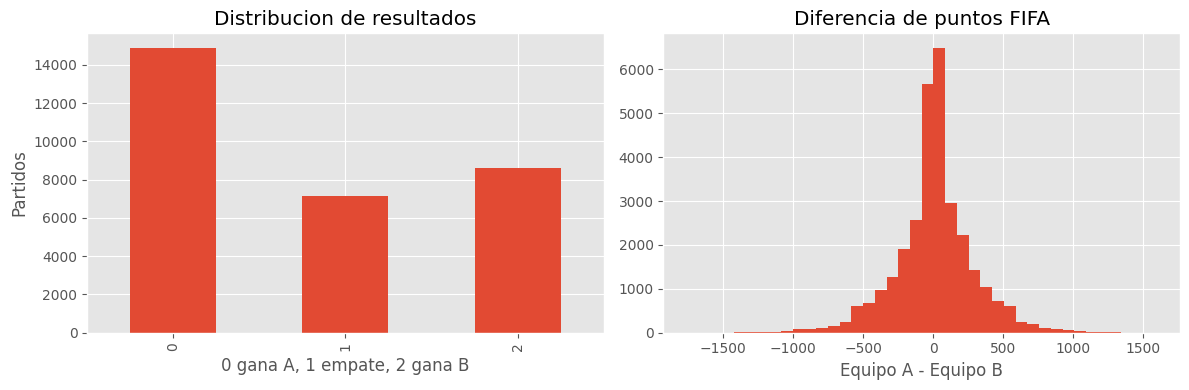

In [14]:
print("Dataset final:", matches.shape)  # Muestra tamano final.
print("Features:", len(feature_cols))  # Muestra numero de features.
print("Partidos de test Mundial 2022:", int(matches["is_world_cup_2022_test"].sum()))  # Verifica test.
display(matches[["date", "home_team", "away_team", "home_score", "away_score", "target_result", "is_world_cup_2022_test"]].tail())  # Muestra ejemplos.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Crea panel de graficos.
matches["target_result"].value_counts().sort_index().plot(kind="bar", ax=axes[0])  # Grafica clases.
axes[0].set_title("Distribucion de resultados")  # Titulo grafico 1.
axes[0].set_xlabel("0 gana A, 1 empate, 2 gana B")  # Etiqueta eje X.
axes[0].set_ylabel("Partidos")  # Etiqueta eje Y.
axes[1].hist(matches["diff_ranking_points"], bins=40)  # Grafica diferencia de ranking.
axes[1].set_title("Diferencia de puntos FIFA")  # Titulo grafico 2.
axes[1].set_xlabel("Equipo A - Equipo B")  # Etiqueta eje X.
plt.tight_layout()  # Ajusta espacios.
plt.show()  # Muestra graficos.